<a href="https://colab.research.google.com/github/ywchanna2001/Protein_Conformational_Ensembles_Prediction/blob/dev/OC23_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OC23 Conformational-Ensemble Evaluation (AFsample2-compatible)

This notebook evaluates predicted PDB ensembles the way **AFsample2** and **AFcluster** do:
by comparing every generated model to the **experimental open and closed reference structures**
with **TM-align** (fixed `d0 = 3.5 Å`), then reporting ensemble-level accuracy.

**It does NOT use pLDDT/pTM as accuracy.** pLDDT is recorded only as a secondary column.

### Metrics produced (all standard in the field)
- **best_tm_s1 / best_tm_s2** — highest TM-score any ensemble member reaches to each reference state.
- **success** — target counts as solved if **both** states are captured (best TM > 0.8 for both), the exact
  AFsample2 criterion. We also sweep the threshold (0.5–1.0) to reproduce their success-vs-threshold (AUC) curve.
- **fill_ratio** — AFsample2's diversity metric: fraction of the open→closed path (100 bins) populated by at least one model.
- **diversity plot** — the TM-to-state1 vs TM-to-state2 scatter, per target.

### Published OC23 baselines to compare against (fraction of 23 targets with BOTH states TM>0.8)
| Method | Success |
|---|---|
| **AFsample2** | **78.3%** |
| SPEACH_AF | 73.9% |
| MSAsubsample | 69.6% |
| AFsample | 56.5% |
| AFvanilla | 47.8% |
| AFcluster | 47.8% |

Source: Kalakoti & Wallner, *Communications Biology* 8:373 (2025), Figs. 3, 4 and Methods.


## 1. Install TM-align


In [ ]:
# Compile official TM-align
!apt-get -qq install -y zstd g++ > /dev/null 2>&1
import os, subprocess
if not os.path.exists('TMalign'):
    !wget -q https://zhanggroup.org/TM-align/TMalign.cpp -O TMalign.cpp
    !g++ -O3 -ffast-math -o TMalign TMalign.cpp
    !chmod +x TMalign
# make it callable as 'TMalign'
os.environ['PATH'] = os.getcwd() + ':' + os.environ['PATH']
print(subprocess.run(['./TMalign','-h'],capture_output=True,text=True).stdout[:200] or "TMalign ready")



 *********************************************************************
 * TM-align (Version 20220412): protein structure alignment          *
 * References: Y Zhang, J Skolnick. Nucl Acids Res 33, 23


## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Get the OC23 reference structures (open/closed PDBs)
Downloads the AFsample2 input dataset from Zenodo and extracts **only** the OC23 reference PDBs
and `filtered_dict.pickle` (which maps each protein to its two reference states). ~226 MB.



In [ ]:
import os, subprocess, pickle, pprint

REF_DIR = '/content/drive/MyDrive/Research/OC23_references'
os.makedirs(REF_DIR, exist_ok=True)

tar_path = os.path.join(REF_DIR, 'input_datasets.tar.zst')
if not os.path.exists(os.path.join(REF_DIR,'input_datasets','oc23','filtered_dict.pickle')):
    if not os.path.exists(tar_path):
        print("Downloading input_datasets.tar.zst from Zenodo (~226 MB)...")
        !wget -q https://zenodo.org/records/14534088/files/input_datasets.tar.zst -O "$tar_path"
    print("Extracting OC23 references...")
    subprocess.run(['tar','--use-compress-program=unzstd','-xvf',tar_path,
                    '-C',REF_DIR,
                    'input_datasets/oc23/pdbs',
                    'input_datasets/oc23/filtered_dict.pickle',
                    'input_datasets/oc23/fastas'], check=False)
OC23_DIR = os.path.join(REF_DIR,'input_datasets','oc23')
PDBS_DIR = os.path.join(OC23_DIR,'pdbs')
print("Reference PDBs available:", len(os.listdir(PDBS_DIR)) if os.path.isdir(PDBS_DIR) else 'MISSING')


Reference PDBs available: 439


### 3b. Inspect `filtered_dict.pickle` and build the protein → (state1, state2) map
The pickle structure isn't documented, so we print it first, then extract the two reference
PDB filenames for each protein.

In [ ]:
import pickle, os, pprint
with open(os.path.join(OC23_DIR,'filtered_dict.pickle'),'rb') as fh:
    filtered = pickle.load(fh)

print("Type:", type(filtered))
if isinstance(filtered, dict):
    keys = list(filtered.keys())
    print("Num entries:", len(keys))
    print("Example keys:", keys[:5])
    print("\nExample value for", keys[0], ":")
    pprint.pprint(filtered[keys[0]])
else:
    pprint.pprint(filtered[:3] if hasattr(filtered,'__getitem__') else filtered)


Type: <class 'dict'>
Num entries: 45
Example keys: ['A2RJ53', 'O76728', 'P31133', 'P00558', 'P40131']

Example value for A2RJ53 :
('3fto_A', '3drf_A', np.int64(576), 0.50707, 4.66)


In [ ]:
# Build {protein_id: (path_state1, path_state2)} from the pickle.

import glob, os

def find_pdb(name):
    """Locate a reference pdb file by (partial) name inside PDBS_DIR."""
    if name is None: return None
    name = str(name)
    cands = glob.glob(os.path.join(PDBS_DIR, f'*{name}*'))
    return cands[0] if cands else None

def build_ref_map(filtered):
    ref_map = {}
    for prot, info in filtered.items():
        s1 = s2 = None
        if isinstance(info, dict):
            # try common key names — adjust after seeing the printout
            for k in ['state1','open','pdb1','ref1','s1','apo']:
                if k in info: s1 = info[k]; break
            for k in ['state2','closed','pdb2','ref2','s2','holo']:
                if k in info: s2 = info[k]; break
        elif isinstance(info,(list,tuple)) and len(info)>=2:
            s1, s2 = info[0], info[1]
        p1, p2 = find_pdb(s1), find_pdb(s2)
        if p1 and p2:
            ref_map[str(prot)] = (p1, p2)
    return ref_map

ref_map = build_ref_map(filtered)
print(f"Built reference map for {len(ref_map)} / {len(filtered)} proteins")
count = 1
for k in list(ref_map)[:]:
    print(count, ":" ,k, '->', [os.path.basename(x) for x in ref_map[k]])
    count += 1


Built reference map for 45 / 45 proteins
1 : A2RJ53 -> ['3fto_A.pdb', '3drf_A.pdb']
2 : O76728 -> ['4bp8_A.pdb', '4bp9_A.pdb']
3 : P31133 -> ['6yed_A.pdb', '6ye0_A.pdb']
4 : P00558 -> ['2xe6_A.pdb', '2wzd_A.pdb']
5 : P40131 -> ['3tee_A.pdb', '3vjp_A.pdb']
6 : Q7DAU8 -> ['3l6g_A.pdb', '3l6h_A.pdb']
7 : P21589 -> ['7qga_A.pdb', '4h2i_A.pdb']
8 : A0QTT2 -> ['7cy2_A.pdb', '7cyr_A.pdb']
9 : Q5F9M1 -> ['3zsf_A.pdb', '2yln_A.pdb']
10 : Q9X6R4 -> ['3iuj_A.pdb', '3iuq_A.pdb']
11 : Q18A65 -> ['6hnj_A.pdb', '6hni_A.pdb']
12 : Q9ERE7 -> ['2rqm_A.pdb', '2rqk_A.pdb']
13 : P62495 -> ['2ktv_A.pdb', '2ktu_A.pdb']
14 : A0A075Q0W3 -> ['6mka_A.pdb', '6mkj_A.pdb']
15 : P71447 -> ['2wfa_A.pdb', '2wf5_A.pdb']
16 : P33284 -> ['3o6w_A.pdb', '3o8m_A.pdb']
17 : Q9Z4N6 -> ['1si1_A.pdb', '1si0_A.pdb']
18 : A6UVT1 -> ['6hac_A.pdb', '6hae_A.pdb']
19 : B7IE18 -> ['6nc7_A.pdb', '6nc6_A.pdb']
20 : B3EYN2 -> ['5ho2_A.pdb', '5ho0_A.pdb']
21 : Q53W80 -> ['7c63_A.pdb', '7c66_A.pdb']
22 : Q9SS90 -> ['6k8b_A.pdb', '6k85_B.pd

## 4. Configuration — point to  predicted ensembles

In [ ]:
PRED_ROOT = '/content/drive/MyDrive/Research/final_predictions/OC23'
OUT_DIR   = '/content/drive/MyDrive/Research/final_evaluation_OC23'
os.makedirs(OUT_DIR, exist_ok=True)

SUCCESS_TM = 0.8   # AFsample2 primary success threshold = 0.80 (both states)
NCPU       = 4

# Map each prediction folder -> protein id used in ref_map.
# Prediction folders are named like 'Q18A65_ab12c'. We strip the hash to get the UniProt id.
import re
def folder_to_protein(folder_name):
    return re.split(r'[_\.]', folder_name)[0]   # 'Q18A65_ab12c' -> 'Q18A65'

pred_folders = [f for f in os.listdir(PRED_ROOT) if os.path.isdir(os.path.join(PRED_ROOT,f))]
print("Prediction folders found:", pred_folders)


Prediction folders found: ['Q9UBV7', 'Q9Z4N6', 'A0A075Q0W3', 'A0A1J6PWI8', 'A0QTT2', 'A0R629', 'A2RJ53', 'A6UVT1', 'B3EYN2', 'B7IE18', 'C7C425', 'J9UN47', 'O34926', 'O76728', 'P00558', 'P00918', 'P0A4G2', 'P0CG48', 'P14902', 'P15291', 'P18031', 'P18965', 'P21589', 'P29350', 'P31133', 'P33284', 'P40131', 'P48635', 'P61316', 'P62495', 'P71447', 'P76045', 'P9WNX1', 'Q18A65', 'Q53W80', 'Q5F9M1', 'Q72HW2', 'Q7DAU8', 'Q82GL5', 'Q8A5V9', 'Q9ERE7', 'Q9SS90', 'Q9U6Y3', 'Q9X6R4', 'Q9X9P9']


In [ ]:
# Restrict to OC23: the 23 open/closed targets where the two states differ (tm_ref < 0.85)
OC23 = {p for p, info in filtered.items()
        if isinstance(info, (list, tuple)) and len(info) >= 4 and float(info[3]) < 0.85}
print(f"OC23 targets: {len(OC23)}  (should be 23)")

OC23 targets: 23  (should be 23)


## 5. TM-align wrapper (identical parsing to AFsample2's `analyse_models.py`)

In [ ]:
!pip install -q biopython

In [ ]:
import subprocess, glob, numpy as np, pandas as pd
from pathlib import Path
from multiprocessing import Pool
from Bio.PDB import PDBParser

def tmalign(model, reference, tmalign_path='./TMalign'):
    """Return TM-score normalized with user-specified d0=3.5 (AFsample2 convention)."""
    try:
        r = subprocess.run([tmalign_path, model, reference, '-d', '3.5'],
                           capture_output=True, text=True, check=True)
    except subprocess.CalledProcessError as e:
        return None
    tm = None
    for line in r.stdout.splitlines():
        if 'user-specified d0' in line:
            try:
                seg = line.split('=')[1].split(' ')
                tm = float(seg[1])
            except (IndexError, ValueError):
                pass
    return tm

def mean_plddt(pdb_file):
    """Mean per-residue B-factor = mean pLDDT for AF2 PDBs."""
    try:
        st = PDBParser(QUIET=True).get_structure('s', pdb_file)
        vals = [np.mean([a.get_bfactor() for a in res]) for chain in st[0] for res in chain]
        return float(np.mean(vals))
    except Exception:
        return np.nan

def _score_pair(args):
    model, ref = args
    return tmalign(model, ref)


## 6. Score every model against both reference states

In [ ]:
def list_models(protein_folder):
    # grab all generated PDBs recursively (ColabFold names contain 'unrelaxed'/'rank')
    pdbs = glob.glob(os.path.join(protein_folder, '**', '*.pdb'), recursive=True)
    return sorted(pdbs)

per_model_rows = []
per_target_rows = []

for folder in pred_folders:
    prot = folder_to_protein(folder)
    if prot not in OC23:
      continue
    if prot not in ref_map:
        print(f"[skip] {folder}: no reference for protein '{prot}'")
        continue
    ref1, ref2 = ref_map[prot]
    models = list_models(os.path.join(PRED_ROOT, folder))
    if not models:
        print(f"[skip] {folder}: no PDBs found"); continue
    print(f"[{prot}] scoring {len(models)} models ...")

    with Pool(NCPU) as pool:
        tm1 = pool.map(_score_pair, [(m, ref1) for m in models])
        tm2 = pool.map(_score_pair, [(m, ref2) for m in models])
    plddt = [mean_plddt(m) for m in models]

    # TM between the two experimental states (needed for fill-ratio)
    tm_ref = tmalign(ref1, ref2)

    for m, a, b, c in zip(models, tm1, tm2, plddt):
        per_model_rows.append({'protein':prot,'model':os.path.basename(m),
                               'tm_s1':a,'tm_s2':b,'plddt':c})
    dfp = pd.DataFrame({'tm_s1':tm1,'tm_s2':tm2})
    dfp = dfp.dropna()
    best1, best2 = dfp['tm_s1'].max(), dfp['tm_s2'].max()
    per_target_rows.append({'protein':prot,'n_models':len(dfp),
                            'tm_ref_open_closed':tm_ref,
                            'best_tm_s1':best1,'best_tm_s2':best2,
                            'min_best':min(best1,best2),
                            'success': bool(best1>SUCCESS_TM and best2>SUCCESS_TM)})

model_df  = pd.DataFrame(per_model_rows)
target_df = pd.DataFrame(per_target_rows)
model_df.to_csv(os.path.join(OUT_DIR,'per_model_scores.csv'), index=False)
target_df.to_csv(os.path.join(OUT_DIR,'per_target_summary.csv'), index=False)
target_df


[Q9Z4N6] scoring 100 models ...
[A0A075Q0W3] scoring 100 models ...
[A0QTT2] scoring 100 models ...
[A2RJ53] scoring 100 models ...
[A6UVT1] scoring 100 models ...
[B3EYN2] scoring 100 models ...
[B7IE18] scoring 100 models ...
[O76728] scoring 100 models ...
[P00558] scoring 100 models ...
[P21589] scoring 100 models ...
[P31133] scoring 100 models ...
[P33284] scoring 100 models ...
[P40131] scoring 100 models ...
[P62495] scoring 100 models ...
[P71447] scoring 100 models ...
[Q18A65] scoring 100 models ...
[Q53W80] scoring 100 models ...
[Q5F9M1] scoring 100 models ...
[Q7DAU8] scoring 100 models ...
[Q9ERE7] scoring 100 models ...
[Q9SS90] scoring 100 models ...
[Q9X6R4] scoring 100 models ...
[Q9X9P9] scoring 100 models ...


,protein,n_models,tm_ref_open_closed,best_tm_s1,best_tm_s2,min_best,success
0,Q9Z4N6,100,0.74881,0.95894,0.94203,0.94203,True
1,A0A075Q0W3,100,0.71961,0.77669,0.81114,0.77669,True
2,A0QTT2,100,0.63521,0.85366,0.82641,0.82641,True
3,A2RJ53,100,0.50707,0.92029,0.95996,0.92029,True
4,A6UVT1,100,0.75385,0.82725,0.86588,0.82725,True
5,B3EYN2,100,0.76573,0.81780,0.83285,0.81780,True
6,B7IE18,100,0.75480,0.85092,0.91575,0.85092,True
7,O76728,100,0.52324,0.59476,0.96321,0.59476,False
8,P00558,100,0.59788,0.95070,0.57662,0.57662,False
9,P21589,100,0.62122,0.62748,0.91622,0.62748,False


## 7. Fill-ratio (AFsample2 diversity metric)

In [ ]:
def fill_ratio(tm_s1, tm_s2, tm_ref, nbins=100):
    """Replicates AFsample2 Methods: fraction of open->closed path bins populated,
    with parabolic weighting emphasizing the two ends."""
    import numpy as np
    tm_s1 = np.asarray(tm_s1); tm_s2 = np.asarray(tm_s2)
    # Q1 = models close to both references
    mask = (tm_s1 >= tm_ref) & (tm_s2 >= tm_ref)
    x, y = tm_s1[mask], tm_s2[mask]
    m, q = -1.0, 1.0 + tm_ref
    L = np.sqrt(2) * (1.0 - tm_ref)
    if L <= 0: return 0.0
    binw = L / nbins
    k_all = np.arange(nbins)
    w = 1 + 16*((k_all/(nbins-1)) - 0.5)**2
    populated = set()
    for xi, yi in zip(x, y):
        xp = (xi + m*yi - m*q)/(m*m+1); yp = m*xp + q
        s = np.sqrt((xp-tm_ref)**2 + (yp-1.0)**2)
        k = int(np.clip(np.floor(s/binw), 0, nbins-1))
        populated.add(k)
    return float(sum(w[k] for k in populated) / w.sum())

fr = []
for _, r in target_df.iterrows():
    sub = model_df[model_df.protein==r.protein].dropna(subset=['tm_s1','tm_s2'])
    fr.append(fill_ratio(sub.tm_s1, sub.tm_s2, r.tm_ref_open_closed))
target_df['fill_ratio'] = fr
target_df.to_csv(os.path.join(OUT_DIR,'per_target_summary.csv'), index=False)
target_df[['protein','best_tm_s1','best_tm_s2','min_best','success','fill_ratio']]


,protein,best_tm_s1,best_tm_s2,min_best,success,fill_ratio
0,Q9Z4N6,0.95894,0.94203,0.94203,True,0.268202
1,A0A075Q0W3,0.77669,0.81114,0.77669,True,0.043990
2,A0QTT2,0.85366,0.82641,0.82641,True,0.096197
3,A2RJ53,0.92029,0.95996,0.92029,True,0.418712
4,A6UVT1,0.82725,0.86588,0.82725,True,0.000000
5,B3EYN2,0.81780,0.83285,0.81780,True,0.040125
6,B7IE18,0.85092,0.91575,0.85092,True,0.182433
7,O76728,0.59476,0.96321,0.59476,False,0.158727
8,P00558,0.95070,0.57662,0.57662,False,0.000000
9,P21589,0.62748,0.91622,0.62748,False,0.061915


## 8. Diversity plots (TM-to-state1 vs TM-to-state2), per target

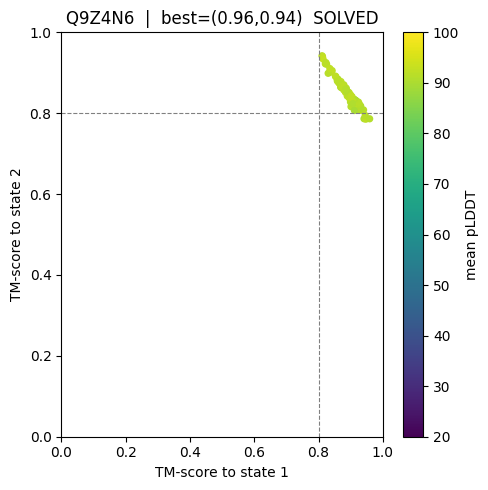

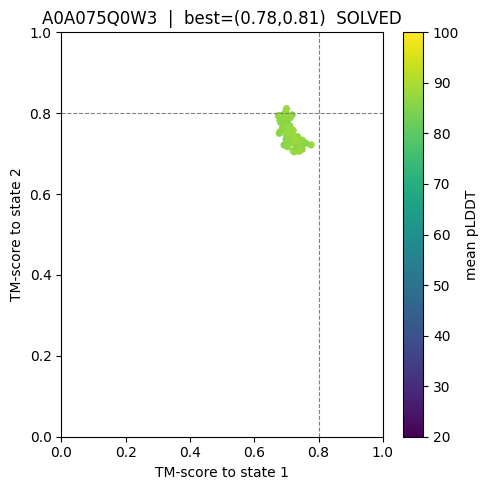

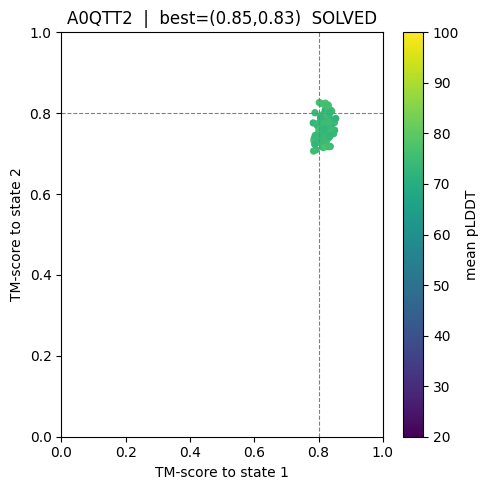

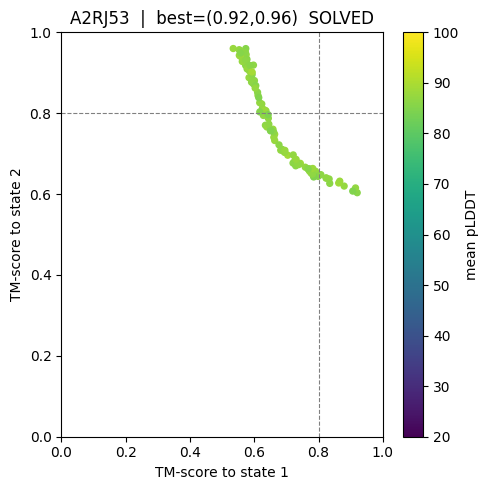

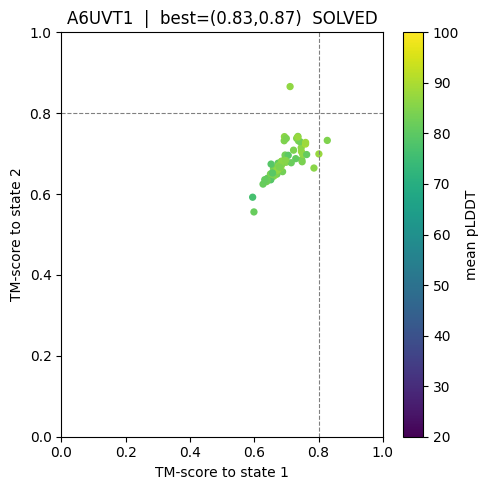

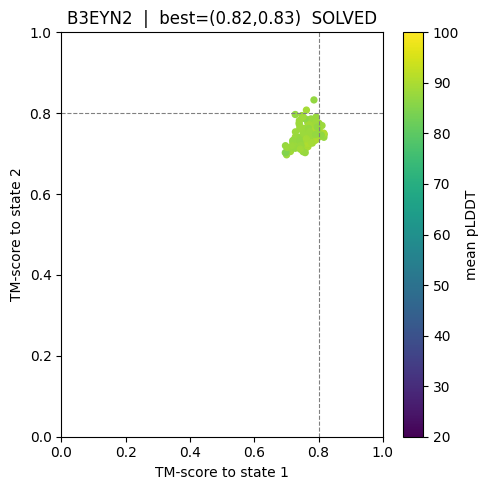

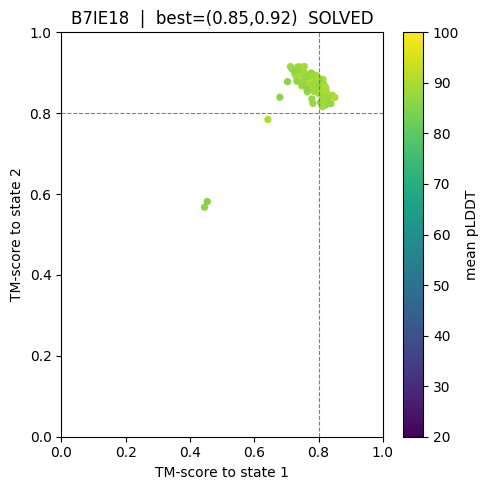

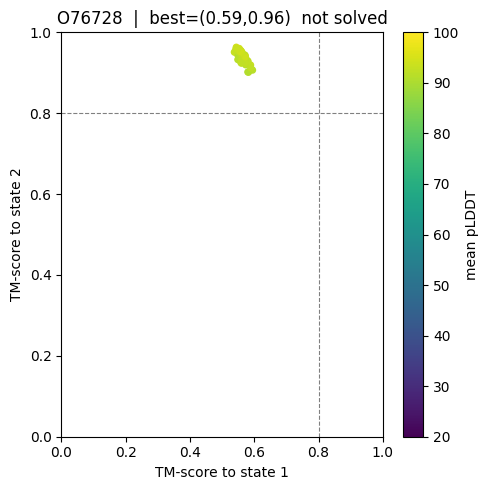

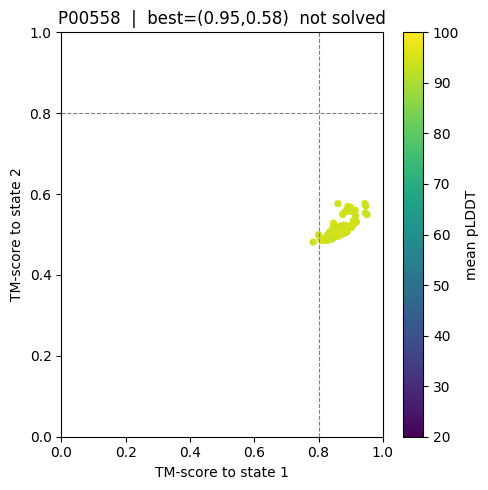

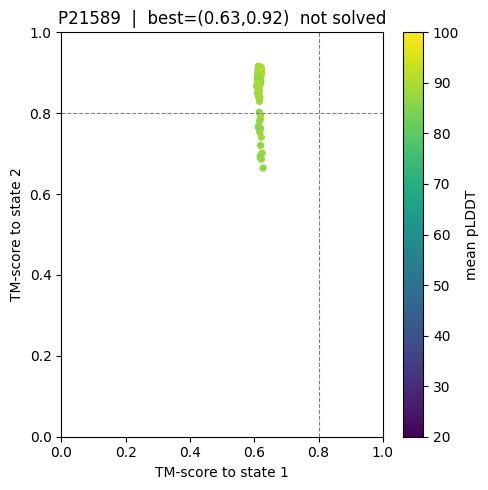

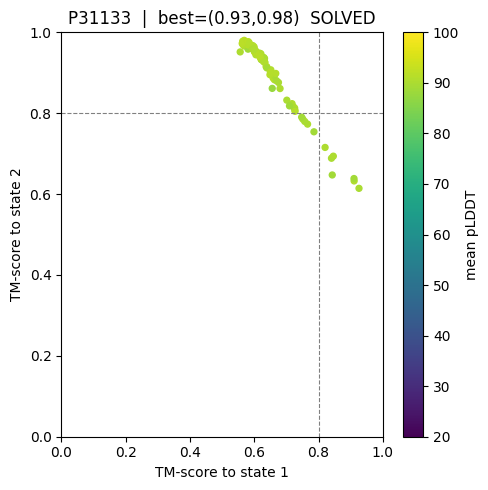

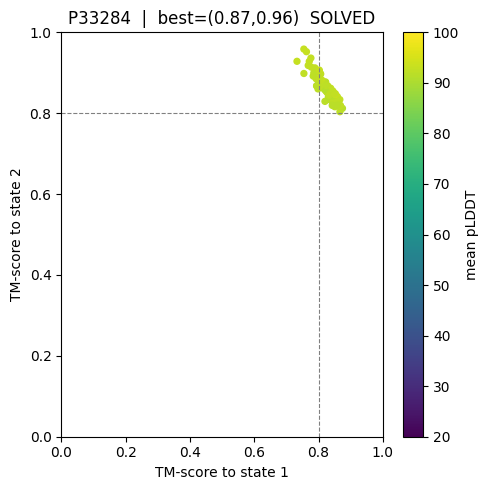

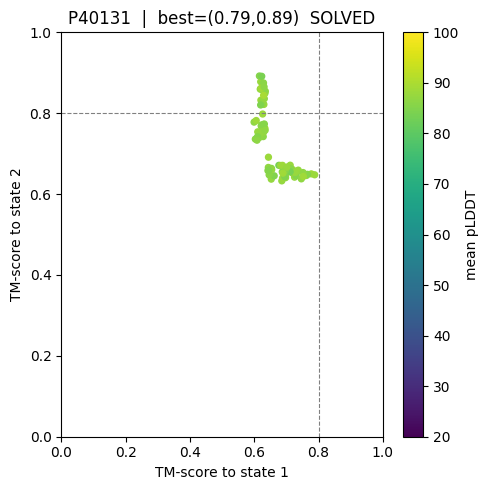

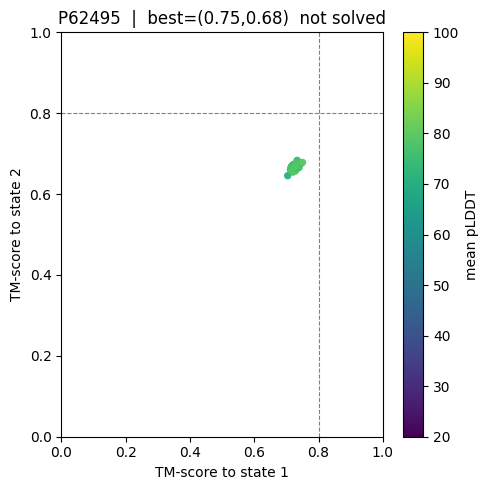

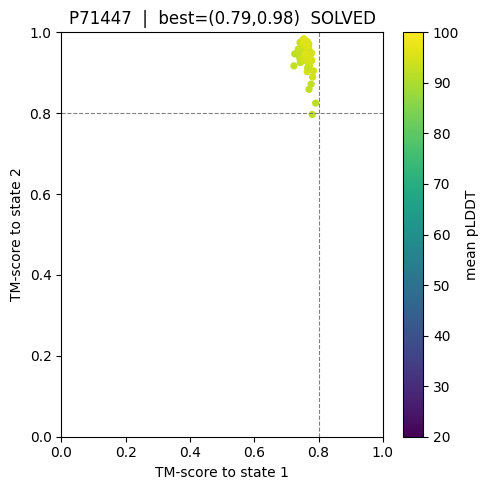

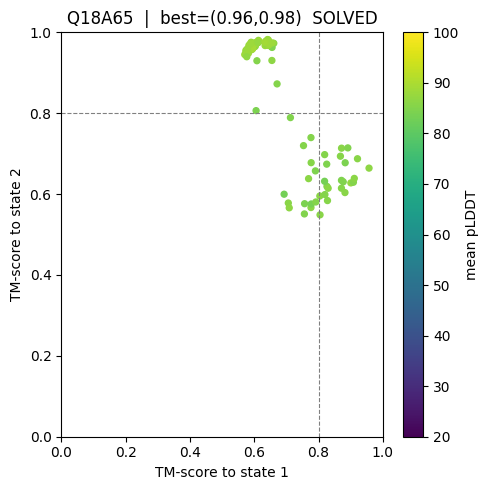

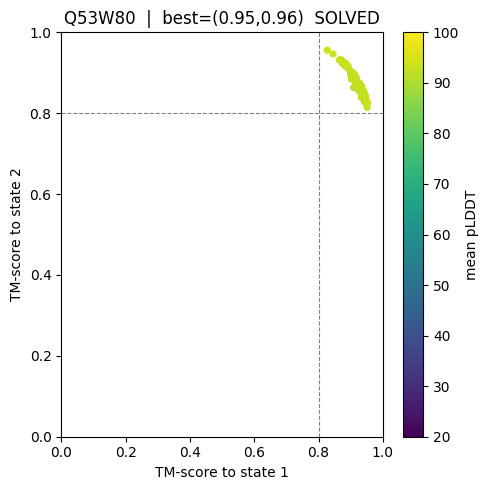

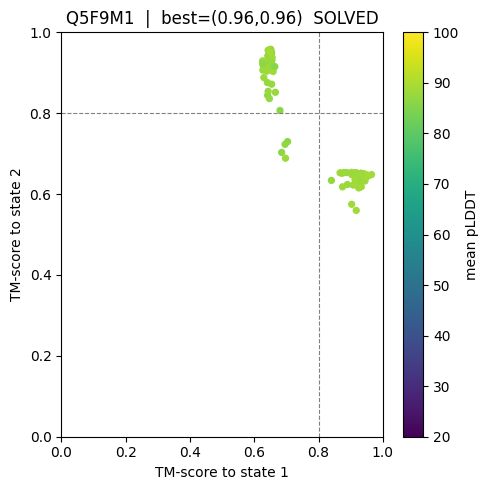

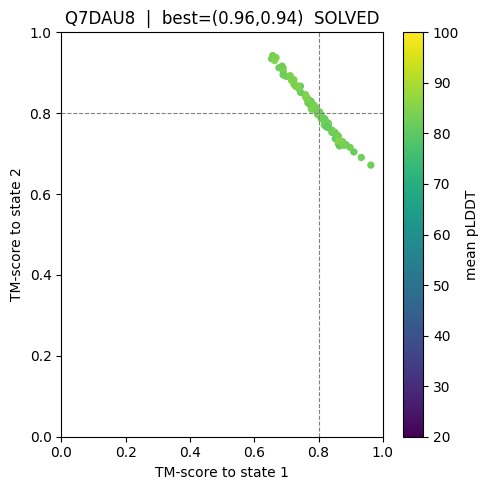

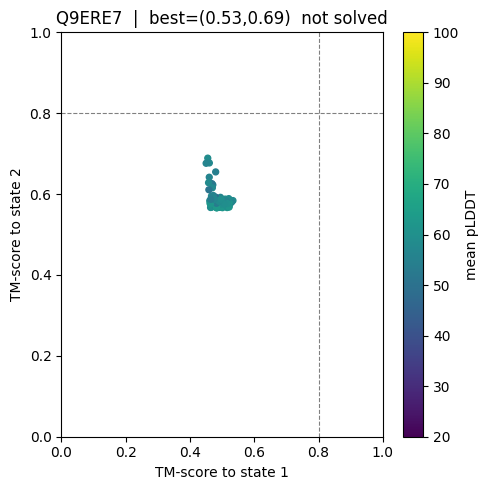

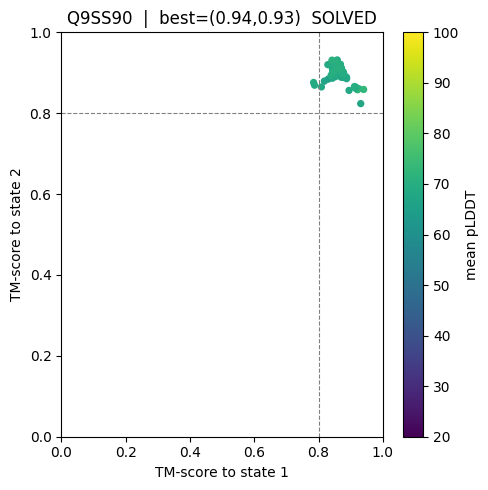

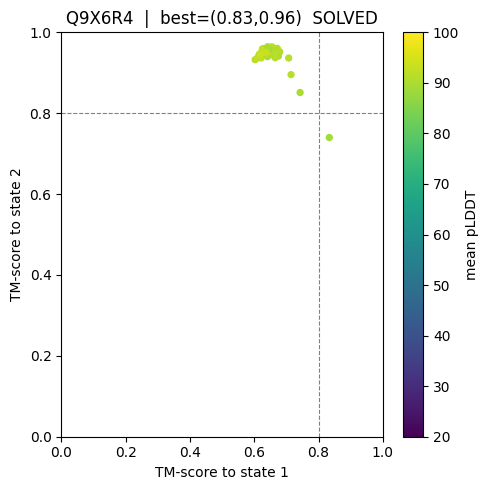

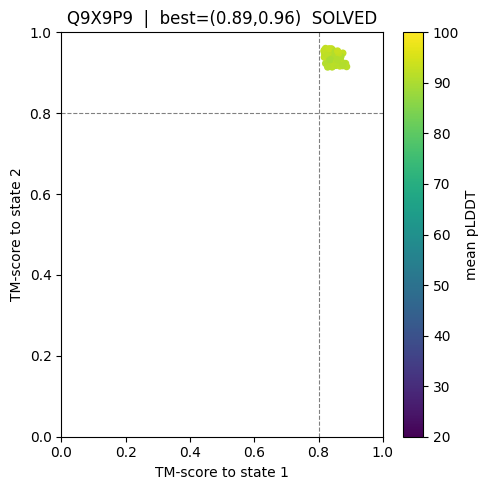

In [ ]:
import matplotlib.pyplot as plt
for prot in target_df.protein:
    sub = model_df[model_df.protein==prot].dropna(subset=['tm_s1','tm_s2'])
    r = target_df[target_df.protein==prot].iloc[0]
    plt.figure(figsize=(5,5))
    sc = plt.scatter(sub.tm_s1, sub.tm_s2, c=sub.plddt, cmap='viridis', s=18, vmin=20, vmax=100)
    plt.colorbar(sc, label='mean pLDDT')
    plt.axhline(0.8, ls='--', c='gray', lw=0.8); plt.axvline(0.8, ls='--', c='gray', lw=0.8)
    plt.xlabel('TM-score to state 1'); plt.ylabel('TM-score to state 2')
    plt.title(f'{prot}  |  best=({r.best_tm_s1:.2f},{r.best_tm_s2:.2f})  '
              f'{"SOLVED" if r.success else "not solved"}')
    plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'diversity_{prot}.png'), dpi=130)
    plt.show()


## 9. Summary + comparison to published baselines


PROPOSED SYSTEM:  18/23 targets solved (both states TM>0.8) = 78.3%
  mean best_tm_s1 = 0.841
  mean best_tm_s2 = 0.891
  mean fill_ratio = 0.181

Published OC23 baselines (fraction of 23 targets, both states TM>0.8):
  AFsample2 (1000)        78.3%
  SPEACH_AF (1000)        73.9%
  MSAsubsample (1000)     69.6%
  AFsample (1000)         56.5%
  AFvanilla               47.8%
  AFcluster (1000)        47.8%


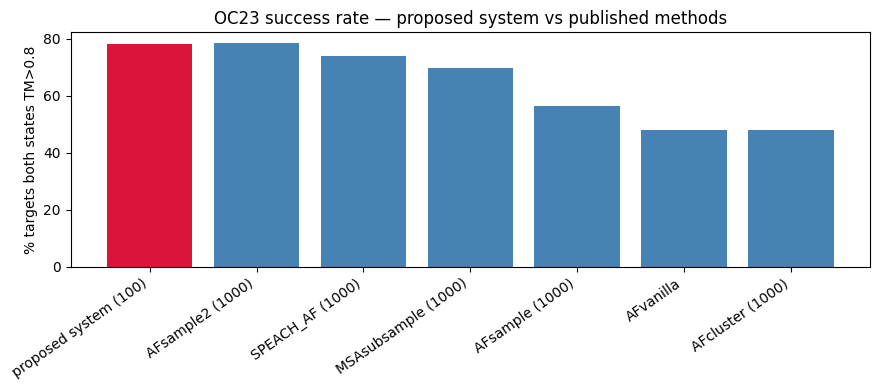

In [ ]:
n = len(target_df)
solved = int(target_df.success.sum())
proposed_pipeline_success = 100.0*solved/n if n else 0.0

baselines = {'AFsample2 (1000)':78.3,'SPEACH_AF (1000)':73.9,'MSAsubsample (1000)':69.6,
             'AFsample (1000)':56.5,'AFvanilla':47.8,'AFcluster (1000)':47.8}
print(f"PROPOSED SYSTEM:  {solved}/{n} targets solved (both states TM>0.8) = {proposed_pipeline_success:.1f}%")
print(f"  mean best_tm_s1 = {target_df.best_tm_s1.mean():.3f}")
print(f"  mean best_tm_s2 = {target_df.best_tm_s2.mean():.3f}")
print(f"  mean fill_ratio = {target_df.fill_ratio.mean():.3f}")
print("\nPublished OC23 baselines (fraction of 23 targets, both states TM>0.8):")
for k,v in baselines.items(): print(f"  {k:22s} {v:5.1f}%")

import matplotlib.pyplot as plt
labels = ['proposed system (100)'] + list(baselines.keys())
vals   = [proposed_pipeline_success] + list(baselines.values())
colors = ['crimson'] + ['steelblue']*len(baselines)
plt.figure(figsize=(9,4))
plt.bar(labels, vals, color=colors)
plt.ylabel('% targets both states TM>0.8'); plt.xticks(rotation=35, ha='right')
plt.title('OC23 success rate — proposed system vs published methods')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'comparison_success.png'), dpi=130); plt.show()
